In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier

print("Libraries loaded.")

Libraries loaded.


In [25]:
df = pd.read_csv("../Data/processed/feature_engineered_data.csv")

X = df.drop("Churned", axis=1)
X = X.drop("City", axis=1)  # Drop 'City' as it has too many unique values
y = df["Churned"]

X = pd.get_dummies(X, drop_first=True)

print(f"Dataset: {X.shape[0]:,} rows | {X.shape[1]} features")
print(f"Churn rate: {y.mean():.1%}")

Dataset: 50,000 rows | 37 features
Churn rate: 28.9%


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")

Train: 40,000 rows | Test: 10,000 rows
Train churn rate: 28.9% | Test churn rate: 28.9%


In [27]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (churners weighted {scale_pos_weight:.1f}x more)")

scale_pos_weight = 2.46  (churners weighted 2.5x more)


In [28]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="auc",
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("Training complete.")

[0]	validation_0-auc:0.90792
[50]	validation_0-auc:0.92575
[100]	validation_0-auc:0.92757
[150]	validation_0-auc:0.92845
[200]	validation_0-auc:0.92914
[250]	validation_0-auc:0.92908
[299]	validation_0-auc:0.92933
Training complete.


In [29]:
y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
avg_prec  = average_precision_score(y_test, y_proba)

print(f"Accuracy         : {accuracy:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")
print(f"Avg Precision    : {avg_prec:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))

Accuracy         : 0.9147
ROC-AUC          : 0.9293
Avg Precision    : 0.9116

Classification Report:
              precision    recall  f1-score   support

      Active       0.94      0.94      0.94      7110
     Churned       0.85      0.85      0.85      2890

    accuracy                           0.91     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.91      0.91      0.91     10000



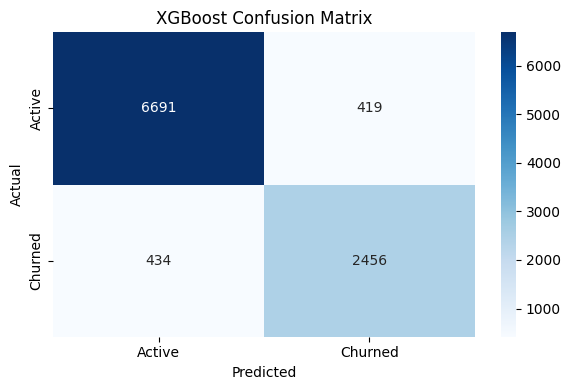

True Negatives  (correct Active)  : 6,691
False Positives (wrong alarm)      : 419
False Negatives (missed churners)  : 434
True Positives  (caught churners)  : 2,456


In [30]:
fig, ax = plt.subplots(figsize=(6, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"],
            ax=ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.savefig("../Reports/xgb_confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct Active)  : {tn:,}")
print(f"False Positives (wrong alarm)      : {fp:,}")
print(f"False Negatives (missed churners)  : {fn:,}")
print(f"True Positives  (caught churners)  : {tp:,}")

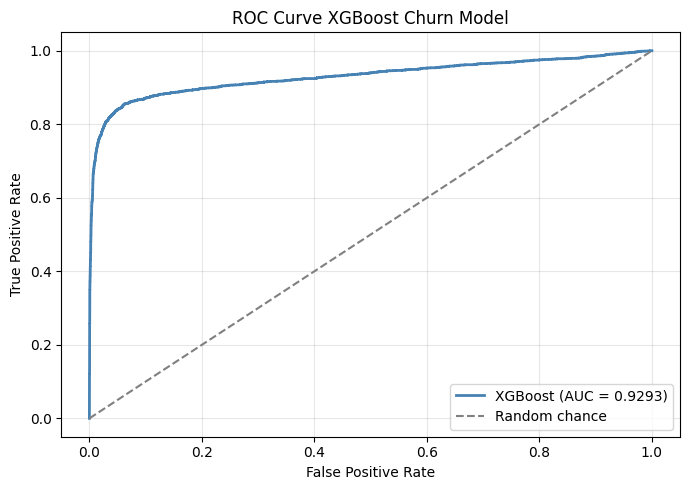

In [31]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"XGBoost (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve XGBoost Churn Model")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Reports/xgb_roc_curve.png", dpi=150)
plt.show()

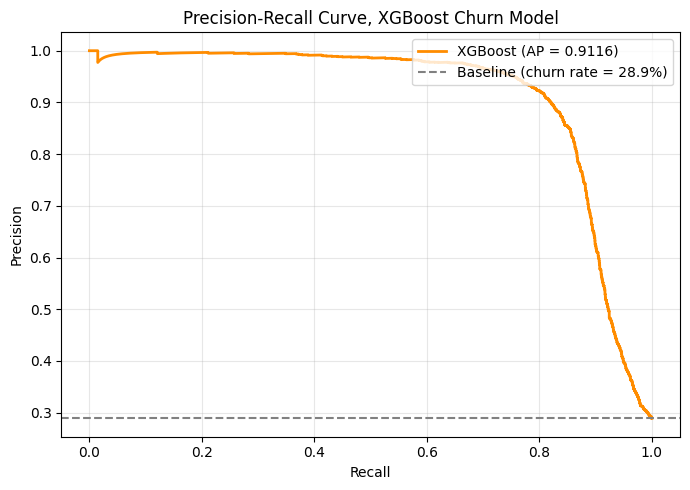

In [32]:
# Precision recall curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="darkorange", lw=2, label=f"XGBoost (AP = {avg_prec:.4f})")
ax.axhline(y=y.mean(), color="grey", linestyle="--", label=f"Baseline (churn rate = {y.mean():.1%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve, XGBoost Churn Model")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Reports/xgb_pr_curve.png", dpi=150)
plt.show()

In [33]:
# 5 fold cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=scale_pos_weight, random_state=42,
        n_jobs=-1, verbosity=0
    ),
    X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("5-Fold Cross-Validation ROC-AUC Scores:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"Mean : {cv_scores.mean():.4f}")
print(f"Std  : {cv_scores.std():.4f}")

5-Fold Cross-Validation ROC-AUC Scores:
  Fold 1: 0.9265
  Fold 2: 0.9228
  Fold 3: 0.9268
  Fold 4: 0.9256
  Fold 5: 0.9354
Mean : 0.9274
Std  : 0.0042


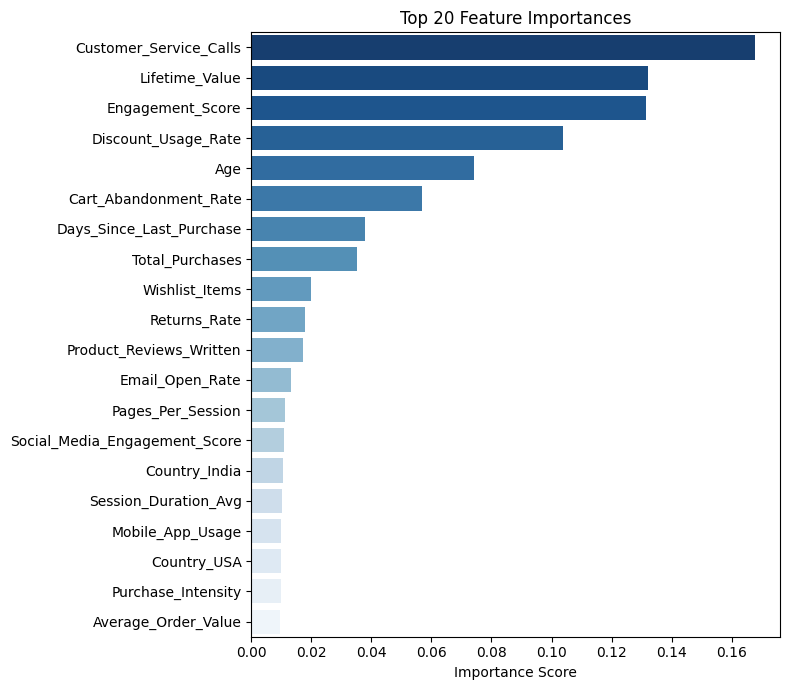

                      Feature  Importance
       Customer_Service_Calls    0.167730
               Lifetime_Value    0.132081
             Engagement_Score    0.131336
          Discount_Usage_Rate    0.103834
                          Age    0.074310
        Cart_Abandonment_Rate    0.056818
     Days_Since_Last_Purchase    0.037744
              Total_Purchases    0.035361
               Wishlist_Items    0.019956
                 Returns_Rate    0.017825
      Product_Reviews_Written    0.017297
              Email_Open_Rate    0.013310
            Pages_Per_Session    0.011146
Social_Media_Engagement_Score    0.010867
                Country_India    0.010399
         Session_Duration_Avg    0.010070
             Mobile_App_Usage    0.010025
                  Country_USA    0.009990
           Purchase_Intensity    0.009799
          Average_Order_Value    0.009655


In [34]:
# Top features
importance_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance" : xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="Blues_r", ax=ax)
ax.set_title("Top 20 Feature Importances")
ax.set_xlabel("Importance Score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../Reports/xgb_feature_importance.png", dpi=150)
plt.show()

print(importance_df.to_string(index=False))

In [35]:
# Save model and feature list
joblib.dump(xgb_model, "../Models/xgb_churn_model.pkl")
joblib.dump(list(X.columns), "../Models/model_features.pkl")

print("Model saved to ../Models/xgb_churn_model.pkl")
print("Feature list saved to ../Models/model_features.pkl")

Model saved to ../Models/xgb_churn_model.pkl
Feature list saved to ../Models/model_features.pkl
